# Electric Vehicle Battery Failure Classification

## Project Overview
This notebook builds a machine learning model that classifies whether an EV battery pack is **Healthy (0)** or **Failed / Failing (1)**, using operational telemetry and physical measurements of the battery pack.

The notebook has two parts:
* **Part 1 — Exploratory Data Analysis (EDA):** understanding the dataset through statistics, distributions, and visualizations.
* **Part 2 — Machine Learning:** preparing the data, training six classification models, tuning them, and picking the best one.

### Why this is useful
* **Predictive maintenance** — fleet operators can schedule servicing before a battery actually fails on the road.
* **Safety** — catching severe degradation early helps prevent thermal runaway incidents.
* **Cost savings** — early detection reduces the cost of full battery replacements.


---
## 1. Import Libraries

We start by importing the libraries we'll use throughout the notebook: `pandas` and `numpy` for handling data, and `matplotlib` / `seaborn` for plotting.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


---
## 2. Load the Dataset

We load the EV battery dataset into a pandas DataFrame and take a first look at it.

In [2]:
import os
dataset_path = os.path.join("data", "ev_battery_health_subset.csv") if os.path.exists(os.path.join("data", "ev_battery_health_subset.csv")) else ("../data/ev_battery_health_subset.csv" if os.path.exists("../data/ev_battery_health_subset.csv") else "ev_battery_health_subset.csv")
df = pd.read_csv(dataset_path)
df.head()

,vehicle_brand,vehicle_type,battery_chemistry,drive_type,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge,battery_failure
0,Nissan,SUV,NaN,AWD,544.0,195563.0,11.17,48.64,0.03349,0.8556,67.6,4.7,59.6,NaN,71.45,11.48,1
1,Tata,Truck,NMC,FWD,1.0,500.0,9.91,0.20,0.01395,0.4191,48.3,41.4,3.0,2016.0,113.53,42.52,0
2,Ford,Sedan,NMC,NaN,584.0,191310.0,6.23,31.01,0.02689,0.6125,58.8,40.5,111.0,2020.0,67.40,11.89,1
3,Tesla,Sedan,NCA,RWD,NaN,107869.0,7.80,17.07,0.02580,0.4472,60.9,41.0,53.4,2018.0,77.72,54.00,0
4,GM,Hatchback,LFP,RWD,1.0,4970.0,5.96,2.86,0.01572,0.5883,28.4,58.4,3.0,2020.0,49.02,49.09,0


# Column Explanation

* **vehicle_brand** → The brand or manufacturer of the electric vehicle.
* **vehicle_type** → The type/category of the electric vehicle.
* **battery_chemistry** → The chemical composition/type of the vehicle's battery.
* **drive_type** → The vehicle's drivetrain type, such as FWD, RWD, or AWD.
* **cycle_count** → The number of charge-discharge cycles completed by the battery.
* **odometer_km** → The total distance travelled by the vehicle in kilometers.
* **vehicle_age_years** → The age of the vehicle in years.
* **capacity_loss_percent** → The percentage of battery capacity lost due to degradation.
* **cell_voltage_std** → The variation in voltage among the battery cells.
* **internal_resistance** → The battery's internal electrical resistance, which affects its performance.
* **thermal_runaway_risk** → The estimated risk of the battery experiencing thermal runaway.
* **battery_stress_index** → A measure representing the overall stress experienced by the battery.
* **daily_distance** → The average distance travelled by the vehicle per day.
* **manufacturing_year** → The year in which the vehicle was manufactured.
* **battery_capacity_kwh** → The total energy storage capacity of the battery in kilowatt-hours.
* **depth_of_discharge** → The percentage of battery capacity used during a discharge cycle.
* **battery_failure** → The target variable indicating whether the battery has failed or not.


In [3]:
df.tail()

,vehicle_brand,vehicle_type,battery_chemistry,drive_type,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge,battery_failure
3995,Tesla,SUV,NMC,FWD,927.0,432659.0,10.15,47.79,0.03646,0.8344,67.3,84.6,140.9,2016.0,NaN,58.90,1
3996,GM,Sedan,NMC,FWD,714.0,257903.0,5.97,33.77,0.02833,0.6587,56.1,46.0,139.9,2020.0,68.43,52.46,1
3997,Nissan,Sedan,NMC,AWD,835.0,372248.0,10.10,46.68,0.03755,0.7640,84.0,65.2,118.0,2016.0,81.79,41.25,1
3998,GM,Truck,LFP,FWD,138.0,76500.0,4.58,3.82,0.01645,0.5955,21.6,31.5,58.6,2021.0,121.33,37.75,0
3999,NaN,Sedan,NMC,RWD,80.0,38179.0,5.05,0.20,0.01531,0.4160,48.0,20.3,NaN,2021.0,87.10,54.83,0


In [4]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.shape

Dataset shape: 4000 rows, 17 columns


(4000, 17)

In [5]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['vehicle_brand', 'vehicle_type', 'battery_chemistry', 'drive_type', 'cycle_count', 'odometer_km', 'vehicle_age_years', 'capacity_loss_percent', 'cell_voltage_std', 'internal_resistance', 'thermal_runaway_risk', 'battery_stress_index', 'daily_distance', 'manufacturing_year', 'battery_capacity_kwh', 'depth_of_discharge', 'battery_failure']


---
## 3. Basic Dataset Information

Before diving into analysis, it helps to check the structure of the data: column types, non-null counts, and summary statistics.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   vehicle_brand          3849 non-null   object 
 1   vehicle_type           3866 non-null   object 
 2   battery_chemistry      3849 non-null   object 
 3   drive_type             3879 non-null   object 
 4   cycle_count            3842 non-null   float64
 5   odometer_km            3834 non-null   float64
 6   vehicle_age_years      3833 non-null   float64
 7   capacity_loss_percent  3797 non-null   float64
 8   cell_voltage_std       3823 non-null   float64
 9   internal_resistance    3834 non-null   float64
 10  thermal_runaway_risk   3870 non-null   float64
 11  battery_stress_index   3847 non-null   float64
 12  daily_distance         3820 non-null   float64
 13  manufacturing_year     3800 non-null   float64
 14  battery_capacity_kwh   3833 non-null   float64
 15  dept

In [7]:
df.describe().round(2)

,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge,battery_failure
count,3842.00,3834.00,3833.00,3797.00,3823.00,3834.00,3870.00,3847.00,3820.00,3800.00,3833.00,3833.00,4000.0
mean,496.07,163962.59,7.55,23.27,0.02,0.63,56.77,44.26,70.21,2018.43,73.38,39.67,0.5
std,391.82,113789.05,2.79,16.92,0.01,0.19,19.24,24.32,38.78,2.78,21.02,12.61,0.5
min,1.00,500.00,1.61,0.20,0.00,0.08,4.90,0.00,3.00,2015.00,25.00,5.00,0.0
25%,182.25,64876.25,5.18,7.40,0.02,0.52,47.70,26.70,39.10,2016.00,58.38,30.98,0.0
50%,425.50,150667.50,8.04,22.78,0.02,0.62,60.60,42.10,69.85,2018.00,72.25,39.67,0.5
75%,721.00,246834.25,9.98,36.92,0.03,0.72,70.00,59.35,101.02,2021.00,87.67,48.34,1.0
max,3200.00,450000.00,11.46,71.18,0.05,3.88,100.00,100.00,192.60,2024.00,141.06,83.49,1.0


In [8]:
df.dtypes

vehicle_brand             object
vehicle_type              object
battery_chemistry         object
drive_type                object
cycle_count              float64
odometer_km              float64
vehicle_age_years        float64
capacity_loss_percent    float64
cell_voltage_std         float64
internal_resistance      float64
thermal_runaway_risk     float64
battery_stress_index     float64
daily_distance           float64
manufacturing_year       float64
battery_capacity_kwh     float64
depth_of_discharge       float64
battery_failure            int64
dtype: object

**Summary:** The dataset has 4,000 rows and 17 columns — 16 predictor features and 1 target column (`battery_failure`). There are 4 categorical features (`vehicle_brand`, `vehicle_type`, `battery_chemistry`, `drive_type`) and 12 numerical features.

---
## 4. Checking Null Values

Here we check for missing values, duplicate rows, and the categories present in each categorical column.

In [9]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percent
})
missing_table.sort_values(by="Missing Count", ascending=False)

,Missing Count,Missing Percentage (%)
capacity_loss_percent,203,5.08
manufacturing_year,200,5.00
daily_distance,180,4.50
cell_voltage_std,177,4.42
depth_of_discharge,167,4.18
battery_capacity_kwh,167,4.18
vehicle_age_years,167,4.18
odometer_km,166,4.15
internal_resistance,166,4.15
cycle_count,158,3.95


In [10]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


In [11]:
print("--- Vehicle Brand ---")
print(df["vehicle_brand"].value_counts())
print("\n--- Vehicle Type ---")
print(df["vehicle_type"].value_counts())
print("\n--- Battery Chemistry ---")
print(df["battery_chemistry"].value_counts())
print("\n--- Drive Type ---")
print(df["drive_type"].value_counts())

--- Vehicle Brand ---
vehicle_brand
Tesla         525
BYD           293
Volkswagen    287
Hyundai       238
Nissan        233
BMW           210
Mercedes      202
Kia           201
GM            191
Renault       188
Ford          177
Toyota        169
Audi          156
Tata          140
Volvo         138
Rivian        124
Honda         105
MG            103
Lucid          85
Mahindra       84
Name: count, dtype: int64

--- Vehicle Type ---
vehicle_type
SUV          1058
Sedan         859
Hatchback     841
Crossover     656
Truck         233
Van           219
Name: count, dtype: int64

--- Battery Chemistry ---
battery_chemistry
NMC    2458
LFP     700
NCA     474
LMO     194
LTO      23
Name: count, dtype: int64

--- Drive Type ---
drive_type
FWD    1757
AWD    1143
RWD     979
Name: count, dtype: int64


**Findings:** Each feature has a small percentage of missing values (roughly 3–5%), while the target column `battery_failure` has no missing values at all. There are no duplicate rows, and all categorical columns contain clean, consistent category labels.

---
## 5. Target Variable Analysis

Let's look at how many batteries are healthy versus failed.

In [12]:
target_counts = df["battery_failure"].value_counts()
target_percent = df["battery_failure"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Class Label": ["Healthy (0)", "Failed (1)"],
    "Count": [target_counts[0], target_counts[1]],
    "Percentage (%)": [target_percent[0], target_percent[1]]
})
target_summary

,Class Label,Count,Percentage (%)
0,Healthy (0),2000,50.0
1,Failed (1),2000,50.0


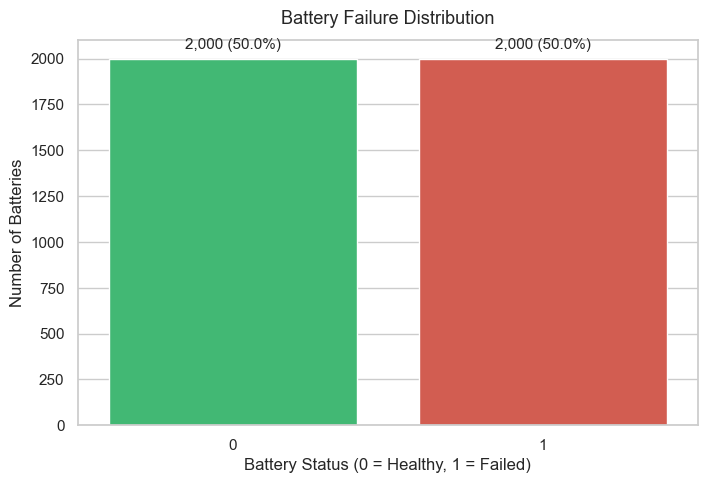

In [13]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Battery Failure Distribution", fontsize=13, pad=12)
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)")
plt.ylabel("Number of Batteries")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height:,} ({height/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width()/2, height),
                ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
plt.show()

**Finding:** The target variable is perfectly balanced — 2,000 healthy batteries and 2,000 failed batteries. This means metrics like accuracy, precision, recall, and F1-score can be used directly without worrying about class imbalance.

---
## 6. Numerical Feature Overview

The dataset contains 12 numerical predictor features. Let's look at their summary statistics.

In [14]:
numerical_columns = [
    "cycle_count", "odometer_km", "vehicle_age_years", "capacity_loss_percent",
    "cell_voltage_std", "internal_resistance", "thermal_runaway_risk",
    "battery_stress_index", "daily_distance", "manufacturing_year",
    "battery_capacity_kwh", "depth_of_discharge"
]
df[numerical_columns].describe().round(2)

,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge
count,3842.00,3834.00,3833.00,3797.00,3823.00,3834.00,3870.00,3847.00,3820.00,3800.00,3833.00,3833.00
mean,496.07,163962.59,7.55,23.27,0.02,0.63,56.77,44.26,70.21,2018.43,73.38,39.67
std,391.82,113789.05,2.79,16.92,0.01,0.19,19.24,24.32,38.78,2.78,21.02,12.61
min,1.00,500.00,1.61,0.20,0.00,0.08,4.90,0.00,3.00,2015.00,25.00,5.00
25%,182.25,64876.25,5.18,7.40,0.02,0.52,47.70,26.70,39.10,2016.00,58.38,30.98
50%,425.50,150667.50,8.04,22.78,0.02,0.62,60.60,42.10,69.85,2018.00,72.25,39.67
75%,721.00,246834.25,9.98,36.92,0.03,0.72,70.00,59.35,101.02,2021.00,87.67,48.34
max,3200.00,450000.00,11.46,71.18,0.05,3.88,100.00,100.00,192.60,2024.00,141.06,83.49


---
## 7. Distribution of Key Numerical Features

We plot a histogram (with a density curve) for each of the main numerical features, to see how each one is spread out.

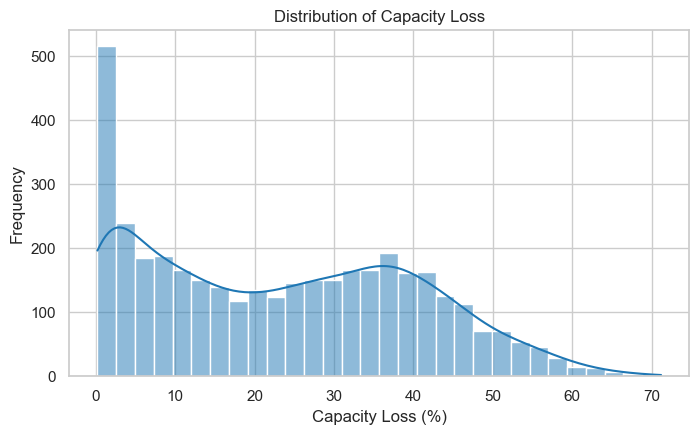

In [15]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["capacity_loss_percent"].dropna(), kde=True, color="#1f77b4", bins=30)
plt.title("Distribution of Capacity Loss")
plt.xlabel("Capacity Loss (%)")
plt.ylabel("Frequency")
plt.show()

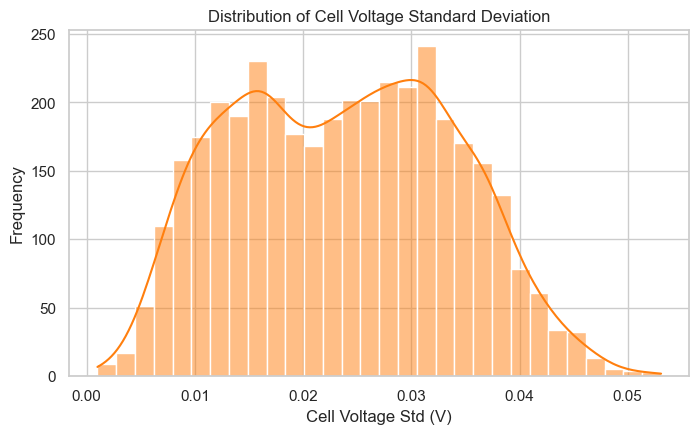

In [16]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["cell_voltage_std"].dropna(), kde=True, color="#ff7f0e", bins=30)
plt.title("Distribution of Cell Voltage Standard Deviation")
plt.xlabel("Cell Voltage Std (V)")
plt.ylabel("Frequency")
plt.show()

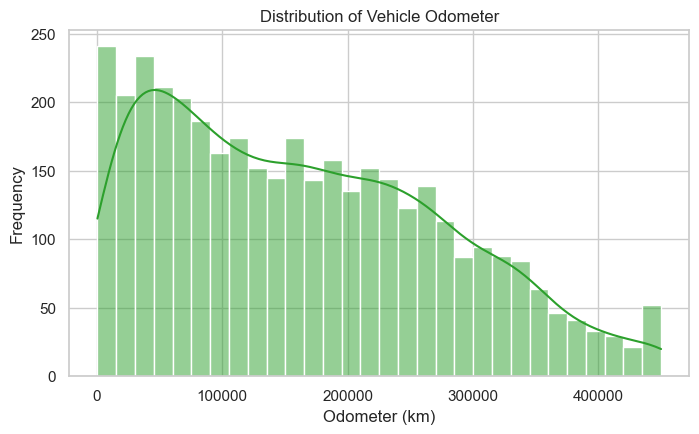

In [17]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["odometer_km"].dropna(), kde=True, color="#2ca02c", bins=30)
plt.title("Distribution of Vehicle Odometer")
plt.xlabel("Odometer (km)")
plt.ylabel("Frequency")
plt.show()

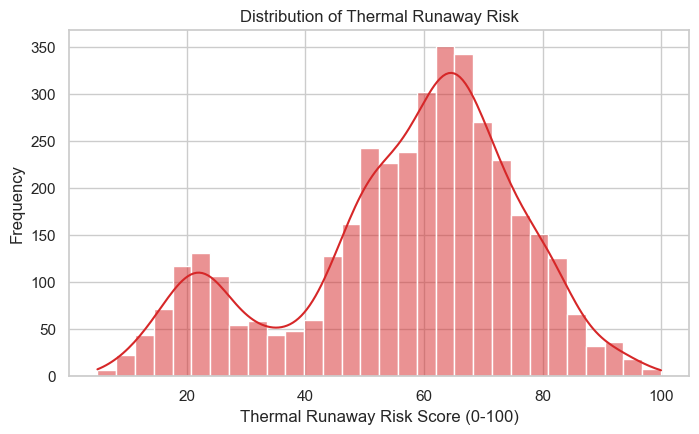

In [18]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["thermal_runaway_risk"].dropna(), kde=True, color="#d62728", bins=30)
plt.title("Distribution of Thermal Runaway Risk")
plt.xlabel("Thermal Runaway Risk Score (0-100)")
plt.ylabel("Frequency")
plt.show()

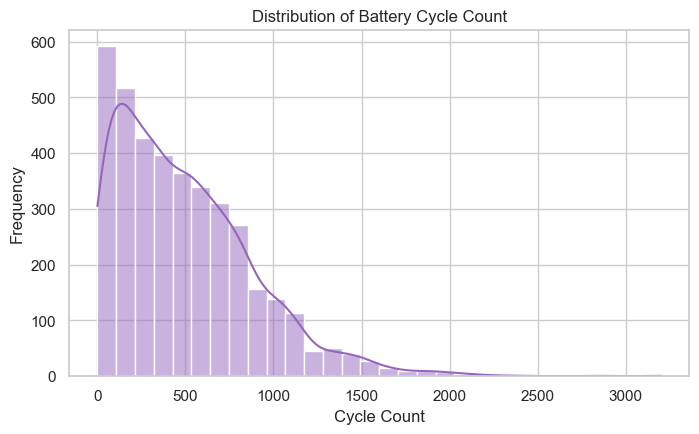

In [19]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["cycle_count"].dropna(), kde=True, color="#9467bd", bins=30)
plt.title("Distribution of Battery Cycle Count")
plt.xlabel("Cycle Count")
plt.ylabel("Frequency")
plt.show()

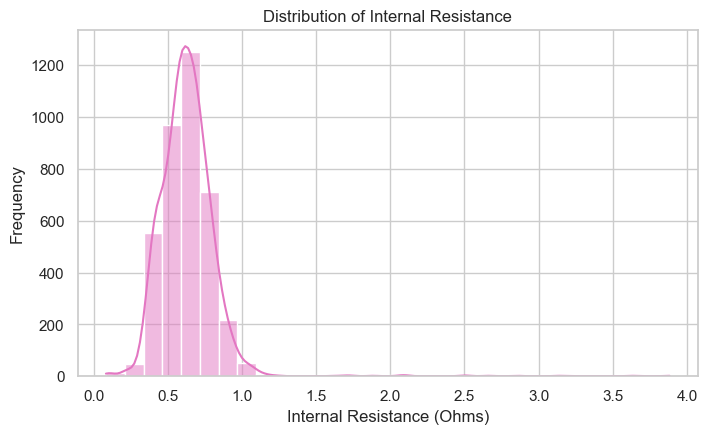

In [20]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["internal_resistance"].dropna(), kde=True, color="#e377c2", bins=30)
plt.title("Distribution of Internal Resistance")
plt.xlabel("Internal Resistance (Ohms)")
plt.ylabel("Frequency")
plt.show()

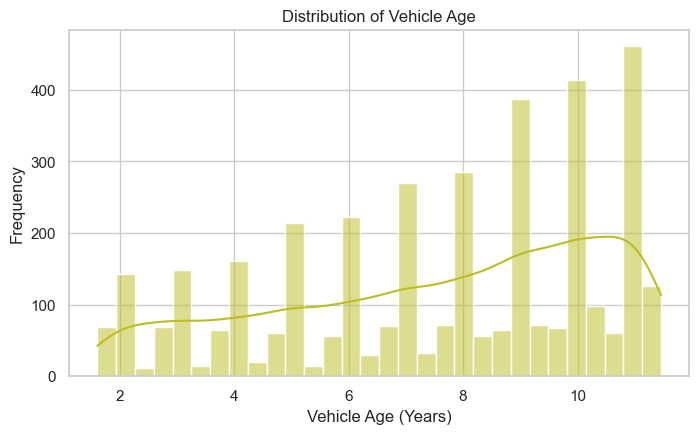

In [21]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["vehicle_age_years"].dropna(), kde=True, color="#bcbd22", bins=30)
plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Frequency")
plt.show()

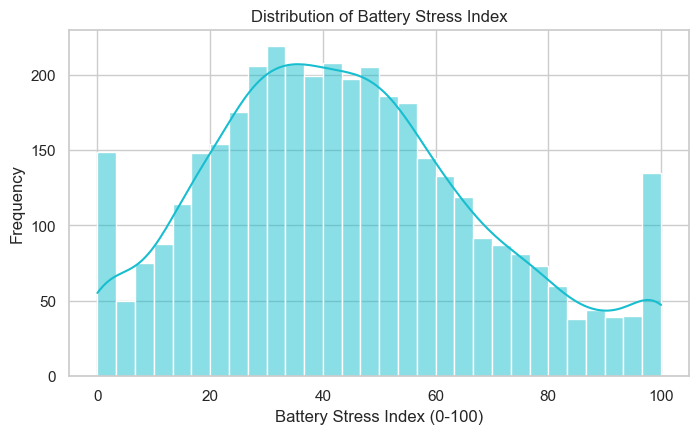

In [22]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["battery_stress_index"].dropna(), kde=True, color="#17becf", bins=30)
plt.title("Distribution of Battery Stress Index")
plt.xlabel("Battery Stress Index (0-100)")
plt.ylabel("Frequency")
plt.show()

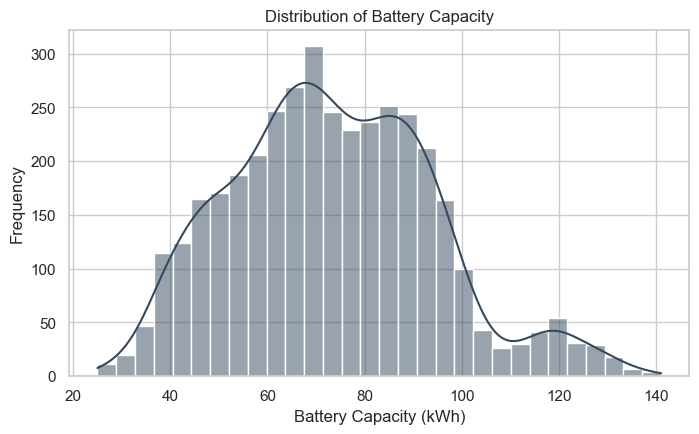

In [23]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["battery_capacity_kwh"].dropna(), kde=True, color="#34495e", bins=30)
plt.title("Distribution of Battery Capacity")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Frequency")
plt.show()

---
## 8. Categorical Features vs Battery Failure

Next, we look at the three main categorical features and how failure rates vary across their categories.

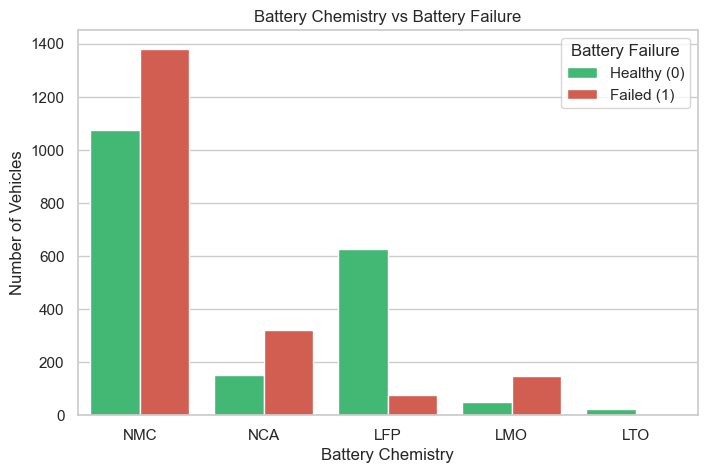

,Healthy (%),Failed (%)
battery_chemistry,,
LMO,24.74,75.26
NCA,32.07,67.93
NMC,43.78,56.22
LFP,89.29,10.71
LTO,100.00,0.00


In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x="battery_chemistry", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Battery Chemistry vs Battery Failure")
plt.xlabel("Battery Chemistry")
plt.ylabel("Number of Vehicles")
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

chem_crosstab = pd.crosstab(df["battery_chemistry"], df["battery_failure"], normalize="index") * 100
chem_crosstab.columns = ["Healthy (%)", "Failed (%)"]
chem_crosstab.round(2).sort_values(by="Failed (%)", ascending=False)

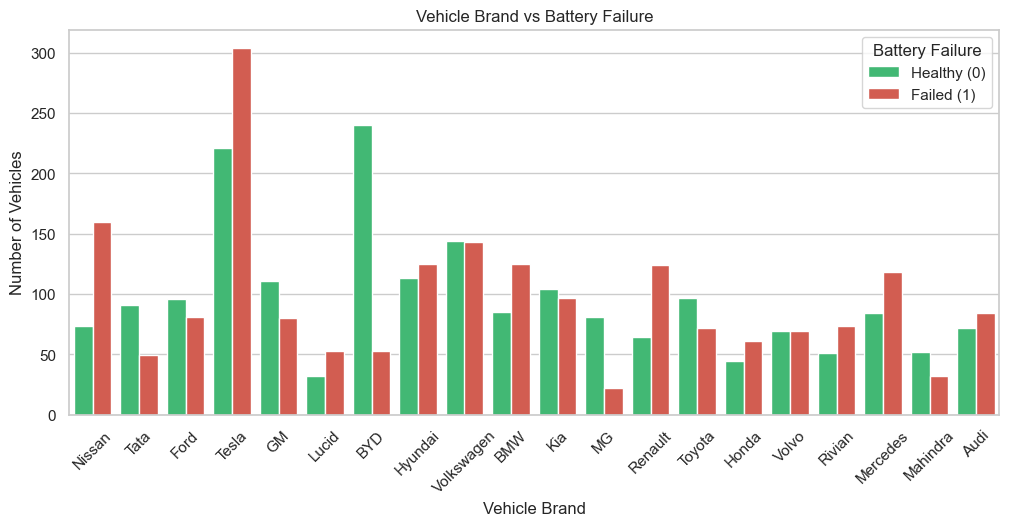

,Healthy (%),Failed (%)
vehicle_brand,,
Nissan,31.33,68.67
Renault,34.04,65.96
Lucid,37.65,62.35
BMW,40.48,59.52
Rivian,41.13,58.87
Mercedes,41.58,58.42
Honda,41.90,58.10
Tesla,42.10,57.90
Audi,46.15,53.85


In [25]:
plt.figure(figsize=(12, 5))
sns.countplot(x="vehicle_brand", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Vehicle Brand vs Battery Failure")
plt.xlabel("Vehicle Brand")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

brand_crosstab = pd.crosstab(df["vehicle_brand"], df["battery_failure"], normalize="index") * 100
brand_crosstab.columns = ["Healthy (%)", "Failed (%)"]
brand_crosstab.round(2).sort_values(by="Failed (%)", ascending=False)

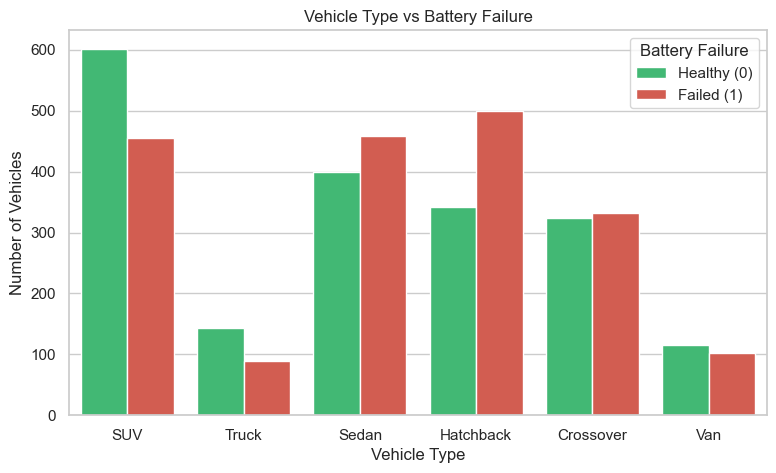

,Healthy (%),Failed (%)
vehicle_type,,
Hatchback,40.67,59.33
Sedan,46.57,53.43
Crossover,49.39,50.61
Van,52.97,47.03
SUV,56.90,43.10
Truck,61.80,38.20


In [26]:
plt.figure(figsize=(9, 5))
sns.countplot(x="vehicle_type", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Vehicle Type vs Battery Failure")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Vehicles")
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

type_crosstab = pd.crosstab(df["vehicle_type"], df["battery_failure"], normalize="index") * 100
type_crosstab.columns = ["Healthy (%)", "Failed (%)"]
type_crosstab.round(2).sort_values(by="Failed (%)", ascending=False)

---
## 9. Checking `drive_type` and `depth_of_discharge`

Two more features are worth checking on their own: `drive_type` (a categorical feature) and `depth_of_discharge` (a numerical feature).

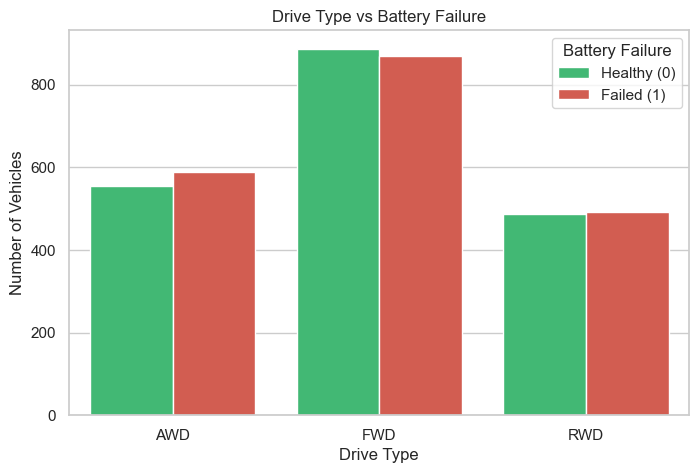

,Healthy (%),Failed (%)
drive_type,,
AWD,48.47,51.53
FWD,50.48,49.52
RWD,49.74,50.26


In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x="drive_type", hue="battery_failure", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Drive Type vs Battery Failure")
plt.xlabel("Drive Type")
plt.ylabel("Number of Vehicles")
plt.legend(title="Battery Failure", labels=["Healthy (0)", "Failed (1)"])
plt.show()

drive_crosstab = pd.crosstab(df["drive_type"], df["battery_failure"], normalize="index") * 100
drive_crosstab.columns = ["Healthy (%)", "Failed (%)"]
drive_crosstab.round(2)

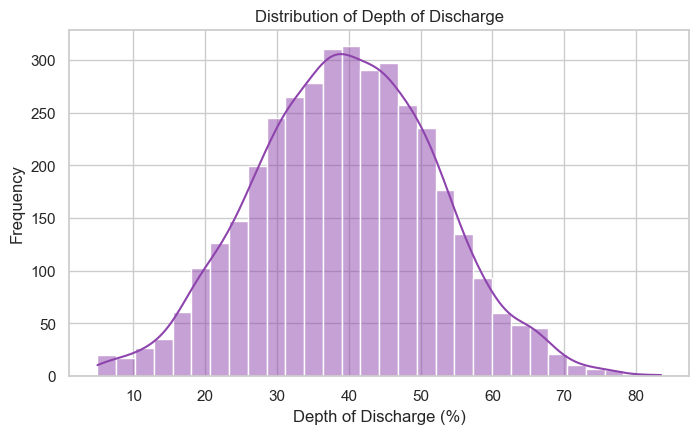

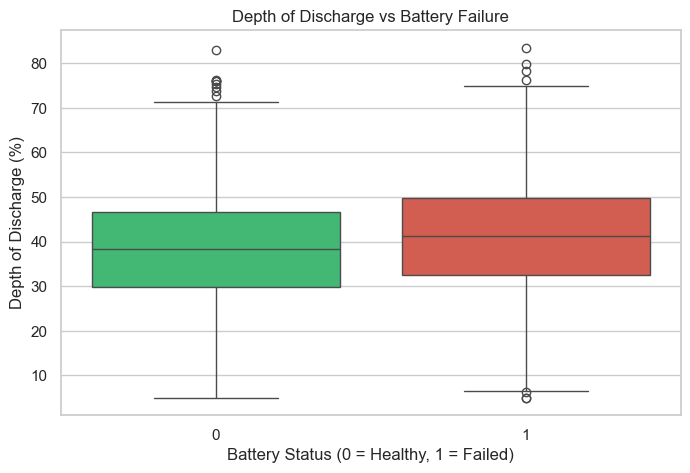

In [28]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["depth_of_discharge"].dropna(), kde=True, color="#8e44ad", bins=30)
plt.title("Distribution of Depth of Discharge")
plt.xlabel("Depth of Discharge (%)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="battery_failure", y="depth_of_discharge", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Depth of Discharge vs Battery Failure")
plt.xlabel("Battery Status (0 = Healthy, 1 = Failed)")
plt.ylabel("Depth of Discharge (%)")
plt.show()

**Observation:** Failure rates for `drive_type` are close to 50% across all three categories (AWD, FWD, RWD), and `depth_of_discharge` looks almost identical for healthy and failed batteries. Both features look like they carry very little useful signal for telling healthy and failed batteries apart — we'll keep this in mind when choosing features for the model.

---
## 10. Correlation Analysis

A correlation heatmap is a quick way to see how the numerical features relate to each other and to spot any pairs of features that carry almost the same information (multicollinearity).

In [29]:
correlation_matrix = df[numerical_columns].corr()
correlation_matrix.round(2)

,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge
cycle_count,1.00,0.86,0.52,0.82,0.75,0.58,0.42,0.23,0.72,-0.52,-0.40,0.07
odometer_km,0.86,1.00,0.60,0.79,0.74,0.53,0.45,0.26,0.84,-0.60,-0.02,0.08
vehicle_age_years,0.52,0.60,1.00,0.49,0.55,0.35,0.30,0.09,0.16,-1.00,-0.03,0.02
capacity_loss_percent,0.82,0.79,0.49,1.00,0.91,0.60,0.74,0.36,0.68,-0.49,-0.29,0.07
cell_voltage_std,0.75,0.74,0.55,0.91,1.00,0.55,0.68,0.33,0.59,-0.54,-0.24,0.07
internal_resistance,0.58,0.53,0.35,0.60,0.55,1.00,0.28,0.35,0.45,-0.35,-0.21,0.07
thermal_runaway_risk,0.42,0.45,0.30,0.74,0.68,0.28,1.00,0.36,0.38,-0.29,-0.15,0.04
battery_stress_index,0.23,0.26,0.09,0.36,0.33,0.35,0.36,1.00,0.30,-0.09,-0.01,0.53
daily_distance,0.72,0.84,0.16,0.68,0.59,0.45,0.38,0.30,1.00,-0.16,-0.01,0.10
manufacturing_year,-0.52,-0.60,-1.00,-0.49,-0.54,-0.35,-0.29,-0.09,-0.16,1.00,0.03,-0.02


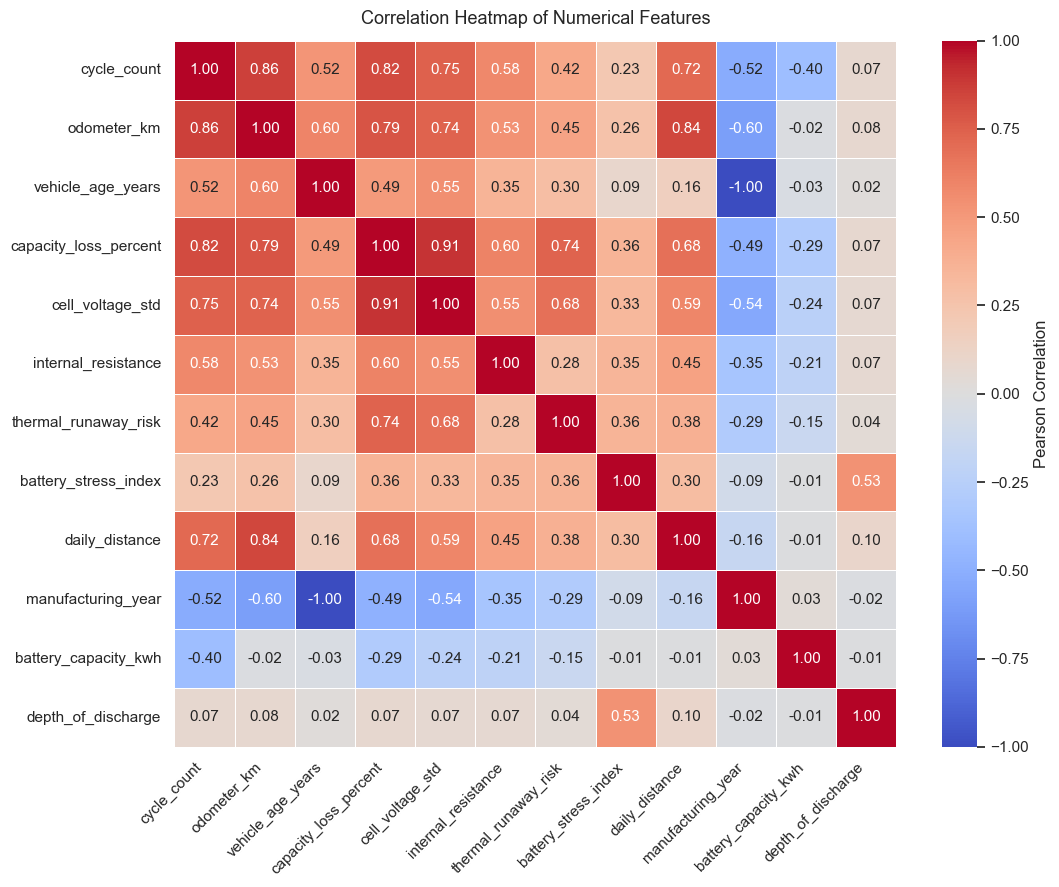

In [30]:
plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Pearson Correlation"})
plt.title("Correlation Heatmap of Numerical Features", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
target_corr = df[numerical_columns + ["battery_failure"]].corr()["battery_failure"].drop("battery_failure")
target_corr.sort_values(ascending=False).round(4)

capacity_loss_percent    0.7892
cell_voltage_std         0.7685
odometer_km              0.6611
thermal_runaway_risk     0.6450
cycle_count              0.6205
daily_distance           0.5444
internal_resistance      0.4880
vehicle_age_years        0.4632
battery_stress_index     0.4506
depth_of_discharge       0.1158
battery_capacity_kwh    -0.1376
manufacturing_year      -0.4652
Name: battery_failure, dtype: float64

**Key findings from the heatmap:**
* `manufacturing_year` and `vehicle_age_years` are almost perfectly (negatively) correlated — they carry the same information about how old the vehicle is.
* `daily_distance` and `odometer_km` are also highly correlated, for the same reason.
* `capacity_loss_percent`, `cell_voltage_std`, `thermal_runaway_risk`, and `battery_stress_index` show the strongest relationship with `battery_failure`.

We'll use these findings when we choose the final set of features for the model in Part 2 — after splitting the data, so the choice is based only on the training portion.

---
## 11. EDA Summary

* The dataset has 4,000 rows, 17 columns, a small amount of missing data (3–5% per column), and no duplicates.
* The target variable is perfectly balanced (50% healthy, 50% failed).
* `capacity_loss_percent`, `cell_voltage_std`, `thermal_runaway_risk`, `battery_stress_index`, `cycle_count`, and `odometer_km` all show a clear difference between healthy and failed batteries.
* `manufacturing_year` duplicates `vehicle_age_years`, and `daily_distance` duplicates `odometer_km`.
* `drive_type` and `depth_of_discharge` show almost no relationship with battery failure.

This wraps up the exploratory part of the project. Part 2 uses these findings to build the machine learning model.

---
# Part 2 — Machine Learning

## 12. Machine Learning Workflow

We'll train and compare 6 different classification models, step by step, without using scikit-learn pipelines — every step (splitting, imputing, encoding, scaling, training, tuning) is done explicitly so it's easy to follow.

**Steps:**
1. Select features and split the data into training and test sets
2. Fill in missing values
3. Choose the final features to use, based on the training data
4. Encode categorical features into numbers
5. Scale numerical features
6. Train 6 classification models
7. Tune each model with GridSearchCV
8. Compare the tuned models and pick the best one
9. Save the final model

An important rule we follow throughout: **the test set is only used at the very end, to check performance.** Every decision along the way — what value to fill missing data with, which features to keep, how to encode categories, how to scale numbers — is learned from the training data only. This keeps the final evaluation honest, since it mirrors how the model would behave on genuinely new data later.

---
## 13. Import Machine Learning Libraries

In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from pandas.api.types import CategoricalDtype

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve
)

import joblib

print("All machine learning libraries imported successfully!")

All machine learning libraries imported successfully!


---
## 14. Select Features (X) and Target (y)

We start with all 16 predictor columns. A few of them will be dropped in a later step, once we've confirmed the decision using the training data.

In [33]:
feature_columns = [col for col in df.columns if col != "battery_failure"]

X = df[feature_columns].copy()
y = df["battery_failure"].copy()

print(f"Features shape (X): {X.shape}")
print(f"Target shape   (y): {y.shape}")

Features shape (X): (4000, 16)
Target shape   (y): (4000,)


---
## 15. Train-Test Split

We split the data into 80% training and 20% testing **before** doing anything else — filling missing values, choosing features, encoding, and scaling will all be based only on the training set from this point on.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train shape: (3200, 16)
X_test shape : (800, 16)

y_train distribution:
battery_failure
1    1600
0    1600
Name: count, dtype: int64

y_test distribution:
battery_failure
1    400
0    400
Name: count, dtype: int64


---
## 16. Handle Missing Values

We fill missing numerical values with the **training median**, and missing categorical values with the **training mode**. The same fill values are then applied to both the training and test sets.

In [35]:
numerical_columns_raw = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns_raw = X_train.select_dtypes(include="object").columns.tolist()

print("Missing values in X_train before filling:")
print(X_train.isnull().sum())

Missing values in X_train before filling:
vehicle_brand            124
vehicle_type             106
battery_chemistry        128
drive_type                88
cycle_count              125
odometer_km              134
vehicle_age_years        139
capacity_loss_percent    166
cell_voltage_std         138
internal_resistance      133
thermal_runaway_risk     107
battery_stress_index     122
daily_distance           150
manufacturing_year       160
battery_capacity_kwh     136
depth_of_discharge       134
dtype: int64


In [36]:
# Numerical columns
X_train[numerical_columns_raw] = X_train[numerical_columns_raw].fillna(
    X_train[numerical_columns_raw].median()
)

X_test[numerical_columns_raw] = X_test[numerical_columns_raw].fillna(
    X_train[numerical_columns_raw].median()
)

# Categorical columns
X_train[categorical_columns_raw] = X_train[categorical_columns_raw].fillna(
    X_train[categorical_columns_raw].mode().iloc[0]
)

X_test[categorical_columns_raw] = X_test[categorical_columns_raw].fillna(
    X_train[categorical_columns_raw].mode().iloc[0]
)

print("Missing values in X_train after filling:", X_train.isnull().sum().sum())
print("Missing values in X_test after filling :", X_test.isnull().sum().sum())

Missing values in X_train after filling: 0
Missing values in X_test after filling : 0


---
## 17. Choose the Final Features

In the EDA, we saw that `manufacturing_year` duplicates `vehicle_age_years`, `daily_distance` duplicates `odometer_km`, and `drive_type` / `depth_of_discharge` carry almost no signal. Let's confirm this using the training data, then finalize the feature list.

In [37]:
train_corr = X_train[numerical_columns_raw].corr()
train_corr.round(2)

,cycle_count,odometer_km,vehicle_age_years,capacity_loss_percent,cell_voltage_std,internal_resistance,thermal_runaway_risk,battery_stress_index,daily_distance,manufacturing_year,battery_capacity_kwh,depth_of_discharge
cycle_count,1.00,0.83,0.50,0.78,0.72,0.54,0.41,0.22,0.69,-0.49,-0.38,0.06
odometer_km,0.83,1.00,0.58,0.75,0.71,0.49,0.43,0.25,0.80,-0.57,-0.02,0.07
vehicle_age_years,0.50,0.58,1.00,0.47,0.52,0.32,0.27,0.07,0.15,-0.95,-0.03,0.00
capacity_loss_percent,0.78,0.75,0.47,1.00,0.86,0.56,0.72,0.34,0.64,-0.46,-0.28,0.07
cell_voltage_std,0.72,0.71,0.52,0.86,1.00,0.51,0.66,0.32,0.56,-0.51,-0.24,0.07
internal_resistance,0.54,0.49,0.32,0.56,0.51,1.00,0.26,0.33,0.42,-0.31,-0.19,0.06
thermal_runaway_risk,0.41,0.43,0.27,0.72,0.66,0.26,1.00,0.35,0.36,-0.27,-0.14,0.05
battery_stress_index,0.22,0.25,0.07,0.34,0.32,0.33,0.35,1.00,0.30,-0.06,-0.01,0.52
daily_distance,0.69,0.80,0.15,0.64,0.56,0.42,0.36,0.30,1.00,-0.14,-0.01,0.10
manufacturing_year,-0.49,-0.57,-0.95,-0.46,-0.51,-0.31,-0.27,-0.06,-0.14,1.00,0.03,-0.01


In [38]:
print("Correlation between manufacturing_year and vehicle_age_years:",
      round(train_corr.loc["manufacturing_year", "vehicle_age_years"], 4))
print("Correlation between daily_distance and odometer_km:",
      round(train_corr.loc["daily_distance", "odometer_km"], 4))

Correlation between manufacturing_year and vehicle_age_years: -0.9489
Correlation between daily_distance and odometer_km: 0.7998


In [39]:
# Final feature list, based on the EDA and the training-set correlation check above
numerical_features = [
    "capacity_loss_percent", "cell_voltage_std", "odometer_km",
    "thermal_runaway_risk", "cycle_count", "internal_resistance",
    "vehicle_age_years", "battery_stress_index", "battery_capacity_kwh"
]

categorical_features = ["battery_chemistry", "vehicle_brand", "vehicle_type"]

selected_features = numerical_features + categorical_features
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print(f"Using {len(numerical_features)} numerical features and {len(categorical_features)} categorical features.")
print(f"Total input features: {len(selected_features)}")

Using 9 numerical features and 3 categorical features.
Total input features: 12


---
## 18. Encode Categorical Variables

We convert `battery_chemistry`, `vehicle_brand`, and `vehicle_type` into numeric dummy columns using `pd.get_dummies`. To make sure `X_train` and `X_test` end up with exactly the same columns, we first fix the list of categories using the training data, then apply one-hot encoding to both.

In [40]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
).astype(int)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
).astype(int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"X_train shape after encoding: {X_train.shape}")
print(f"X_test shape after encoding : {X_test.shape}")

X_train shape after encoding: (3200, 37)
X_test shape after encoding : (800, 37)


---
## 19. Scale Numerical Features

We scale the 9 numerical features using `StandardScaler` (mean = 0, standard deviation = 1). The scaler is fit on the training data only, and then used to transform both the training and test sets.

In [41]:
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Numerical features scaled successfully!")
print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_test shape : {X_test.shape}")
X_train.head()

Numerical features scaled successfully!
Final X_train shape: (3200, 37)
Final X_test shape : (800, 37)


,capacity_loss_percent,cell_voltage_std,odometer_km,thermal_runaway_risk,cycle_count,internal_resistance,vehicle_age_years,battery_stress_index,battery_capacity_kwh,battery_chemistry_LMO,...,vehicle_brand_Tata,vehicle_brand_Tesla,vehicle_brand_Toyota,vehicle_brand_Volkswagen,vehicle_brand_Volvo,vehicle_type_Hatchback,vehicle_type_SUV,vehicle_type_Sedan,vehicle_type_Truck,vehicle_type_Van
3423,1.348684,0.0,1.178559,1.782688,0.654547,-0.11989,0.674734,-0.451065,0.292620,0,...,0,1,0,0,0,0,0,0,0,0
760,-0.842782,0.0,-0.881942,-2.073200,-0.544016,-0.11989,-0.409902,-0.492805,-1.262352,0,...,0,1,0,0,0,1,0,0,0,0
1032,0.131203,0.0,-0.329869,1.571407,-0.302730,-0.11989,-0.048357,0.091554,-0.047530,0,...,0,0,0,0,0,0,1,0,0,0
3676,1.226936,0.0,-0.404038,0.092436,-0.334202,-0.11989,-1.132992,1.260271,-0.484866,1,...,0,1,0,0,0,0,0,1,0,0
2879,-0.903656,0.0,-1.184097,-0.013205,-1.081665,-0.11989,-1.856083,-0.910203,-0.484866,0,...,0,0,0,0,0,0,0,1,0,0


---
## 20. Train 6 Classification Models

We train six different classifiers:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Support Vector Machine (SVM)
6. Gradient Boosting

In [42]:
# 1. Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# 2. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# 3. Decision Tree
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# 4. Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# 5. Support Vector Machine
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# 6. Gradient Boosting
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
gradient_boosting_model.fit(X_train, y_train)

print("All 6 classification models trained successfully!")

All 6 classification models trained successfully!


---
## 21. Evaluate Baseline Models

We compute Accuracy, Precision, Recall, F1 Score, and ROC-AUC on the test set for each model.

In [43]:
# Logistic Regression Evaluation

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

In [44]:
# K-Nearest Neighbors Evaluation

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

In [45]:
# Decision Tree Evaluation

y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

In [46]:
# Random Forest Evaluation

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

In [47]:
# Support Vector Machine Evaluation

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

In [48]:
# Gradient Boosting Evaluation

y_pred_gb = gradient_boosting_model.predict(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Evaluation metrics computed for all 6 models.")

Evaluation metrics computed for all 6 models.


In [66]:
# Compare the performance of all 6 baseline models

baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors", "Decision Tree",
              "Random Forest", "Support Vector Machine", "Gradient Boosting"],
    "Accuracy": [acc_lr, acc_knn, acc_dt, acc_rf, acc_svm, acc_gb],
    "Precision": [prec_lr, prec_knn, prec_dt, prec_rf, prec_svm, prec_gb],
    "Recall": [rec_lr, rec_knn, rec_dt, rec_rf, rec_svm, rec_gb],
    "F1 Score": [f1_lr, f1_knn, f1_dt, f1_rf, f1_svm, f1_gb],
    "ROC-AUC": [auc_lr, auc_knn, auc_dt, auc_rf, auc_svm, auc_gb]
})

# Sort models by F1 Score
baseline_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Support Vector Machine,0.9238,0.9124,0.9375,0.9248,0.9689
1,Gradient Boosting,0.9200,0.9179,0.9225,0.9202,0.9699
2,Logistic Regression,0.9200,0.9242,0.9150,0.9196,0.9758
3,Random Forest,0.9175,0.9113,0.9250,0.9181,0.9678
4,K-Nearest Neighbors,0.8988,0.8862,0.9150,0.9004,0.9534
5,Decision Tree,0.8788,0.8704,0.8900,0.8801,0.8788


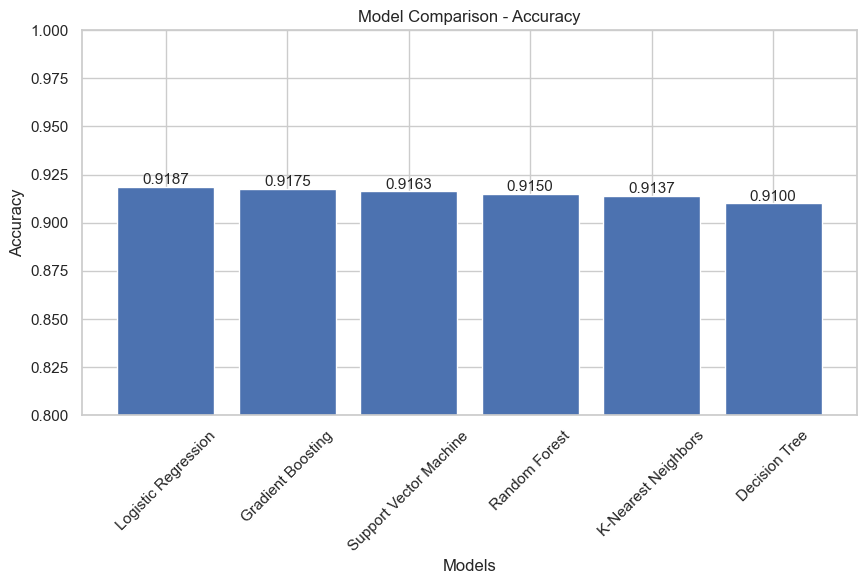

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    tuned_comparison_table["Model"],
    tuned_comparison_table["Test Accuracy"]
)

plt.title("Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)

# Show value on top of each bar
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

---
## 22. Confusion Matrices & Classification Reports

**Reading the confusion matrix:**
* **True Positive** — predicted failure, battery actually failed.
* **True Negative** — predicted healthy, battery actually healthy.
* **False Positive** — predicted failure, but battery was actually healthy (an unnecessary inspection).
* **False Negative** — predicted healthy, but battery actually failed (a missed failure — the costlier mistake).

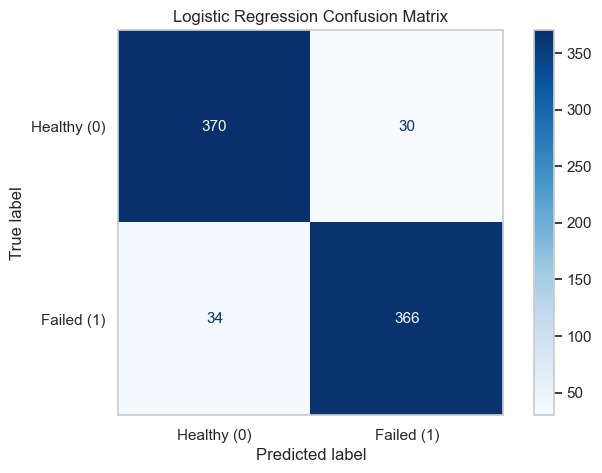

--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

 Healthy (0)       0.92      0.93      0.92       400
  Failed (1)       0.92      0.92      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



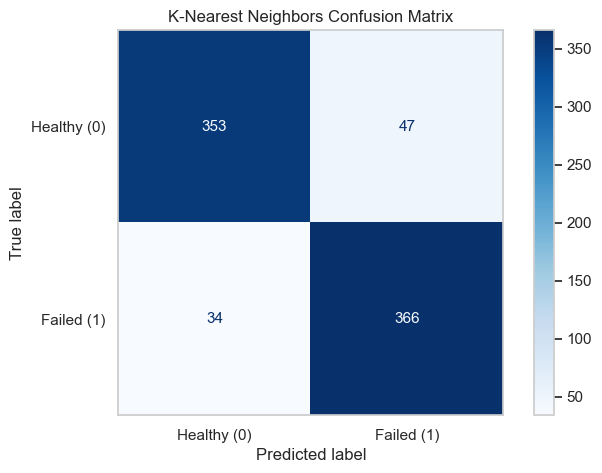

--- Classification Report: K-Nearest Neighbors ---
              precision    recall  f1-score   support

 Healthy (0)       0.91      0.88      0.90       400
  Failed (1)       0.89      0.92      0.90       400

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.90      0.90      0.90       800



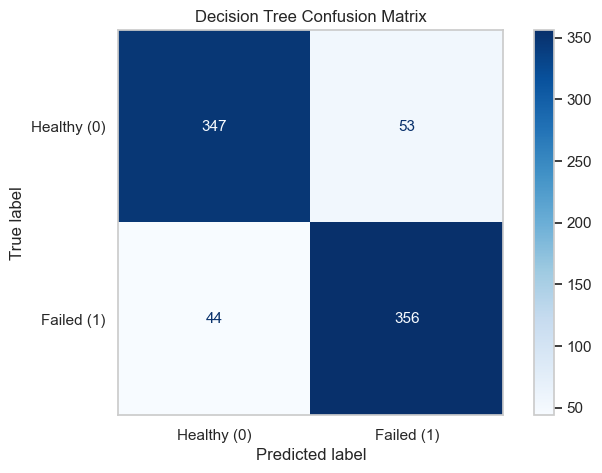

--- Classification Report: Decision Tree ---
              precision    recall  f1-score   support

 Healthy (0)       0.89      0.87      0.88       400
  Failed (1)       0.87      0.89      0.88       400

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800



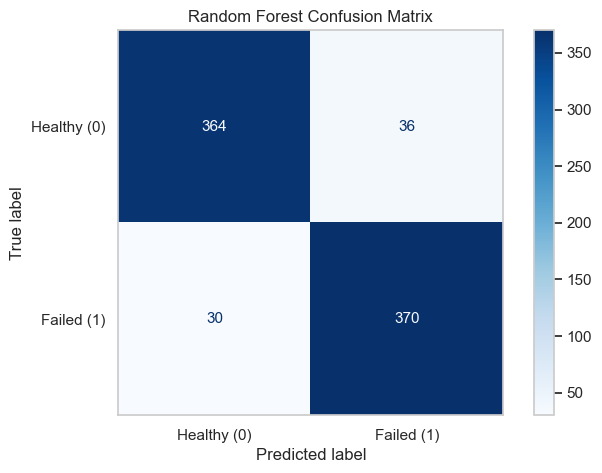

--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

 Healthy (0)       0.92      0.91      0.92       400
  Failed (1)       0.91      0.93      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



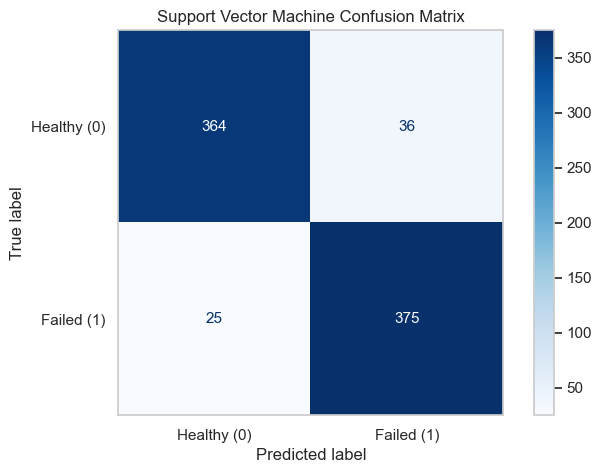

--- Classification Report: Support Vector Machine ---
              precision    recall  f1-score   support

 Healthy (0)       0.94      0.91      0.92       400
  Failed (1)       0.91      0.94      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



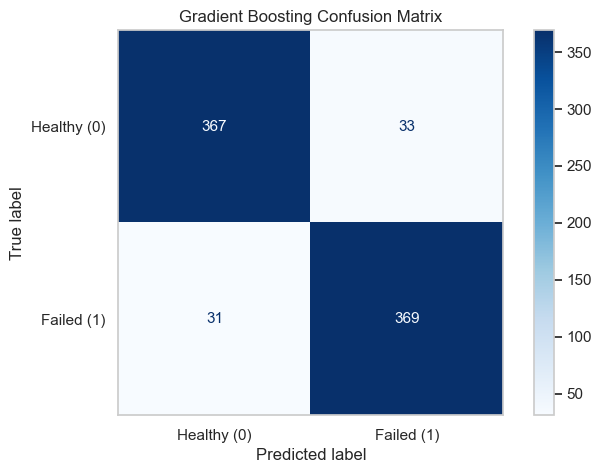

--- Classification Report: Gradient Boosting ---


              precision    recall  f1-score   support

 Healthy (0)       0.92      0.92      0.92       400
  Failed (1)       0.92      0.92      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



In [52]:
models_to_display = [
    ("Logistic Regression", y_pred_lr),
    ("K-Nearest Neighbors", y_pred_knn),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("Support Vector Machine", y_pred_svm),
    ("Gradient Boosting", y_pred_gb)
]

for name, y_pred in models_to_display:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy (0)", "Failed (1)"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.grid(False)
    plt.show()

    print(f"--- Classification Report: {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Healthy (0)", "Failed (1)"]))
    print("=" * 60)

---
## 23. Hyperparameter Tuning with GridSearchCV

We tune each model separately with `GridSearchCV`, using 5-fold cross-validation on the training data and optimizing for F1 score.

Note: for the Support Vector Machine, we tune with `probability=False`, which skips an extra internal calibration step and makes the grid search noticeably faster. We turn probability estimates back on afterwards, only for the version of the SVM we actually keep.

In [53]:
# Tune Logistic Regression parameters
param_grid_lr = {"C": [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring="f1"
)

grid_lr.fit(X_train, y_train)

print(
    "Logistic Regression best params:",
    grid_lr.best_params_,
    "| Best CV F1:",
    round(grid_lr.best_score_, 4)
)

Logistic Regression best params: {'C': 0.01} | Best CV F1: 0.918


In [54]:
# Tune KNN parameters
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="f1"
)

grid_knn.fit(X_train, y_train)

print(
    "KNN best params:",
    grid_knn.best_params_,
    "| Best CV F1:",
    round(grid_knn.best_score_, 4)
)

KNN best params: {'n_neighbors': 11, 'weights': 'distance'} | Best CV F1: 0.9056


In [55]:
# Tune Decision Tree parameters
param_grid_dt = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="f1"
)

grid_dt.fit(X_train, y_train)

print(
    "Decision Tree best params:",
    grid_dt.best_params_,
    "| Best CV F1:",
    round(grid_dt.best_score_, 4)
)

Decision Tree best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2} | Best CV F1: 0.8995


In [56]:
# Tune Random Forest parameters
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1"
)

grid_rf.fit(X_train, y_train)

print(
    "Random Forest best params:",
    grid_rf.best_params_,
    "| Best CV F1:",
    round(grid_rf.best_score_, 4)
)

Random Forest best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200} | Best CV F1: 0.9134


In [57]:
# Tune SVM parameters
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid_svm = GridSearchCV(
    SVC(probability=False, random_state=42),
    param_grid_svm,
    cv=5,
    scoring="f1"
)

grid_svm.fit(X_train, y_train)

print(
    "SVM best params:",
    grid_svm.best_params_,
    "| Best CV F1:",
    round(grid_svm.best_score_, 4)
)

# Train the best SVM again with probability estimates
best_svm_model = SVC(
    probability=True,
    random_state=42,
    **grid_svm.best_params_
)

best_svm_model.fit(X_train, y_train)

SVM best params: {'C': 10, 'kernel': 'linear'} | Best CV F1: 0.9166


,C,10
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [58]:
# Tune Gradient Boosting parameters
param_grid_gb = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 5]
}

# Find the best parameters using GridSearchCV
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring="f1"
)

grid_gb.fit(X_train, y_train)

print(
    "Gradient Boosting best params:",
    grid_gb.best_params_,
    "| Best CV F1:",
    round(grid_gb.best_score_, 4)
)

Gradient Boosting best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150} | Best CV F1: 0.9149


---
## 24. Evaluate Tuned Models & Final Comparison Table

We take the best version of each model and evaluate it on the test set.

In [59]:
# Get the best tuned model from each GridSearchCV

best_lr = grid_lr.best_estimator_
best_knn = grid_knn.best_estimator_
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_
best_gb = grid_gb.best_estimator_

# best_svm_model was already refit above with probability=True

# Generate predictions and probabilities for Logistic Regression
y_pred_best_lr = best_lr.predict(X_test)
y_prob_best_lr = best_lr.predict_proba(X_test)[:, 1]

# Generate predictions and probabilities for KNN
y_pred_best_knn = best_knn.predict(X_test)
y_prob_best_knn = best_knn.predict_proba(X_test)[:, 1]

# Generate predictions and probabilities for Decision Tree
y_pred_best_dt = best_dt.predict(X_test)
y_prob_best_dt = best_dt.predict_proba(X_test)[:, 1]

# Generate predictions and probabilities for Random Forest
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# Generate predictions and probabilities for SVM
y_pred_best_svm = best_svm_model.predict(X_test)
y_prob_best_svm = best_svm_model.predict_proba(X_test)[:, 1]

# Generate predictions and probabilities for Gradient Boosting
y_pred_best_gb = best_gb.predict(X_test)
y_prob_best_gb = best_gb.predict_proba(X_test)[:, 1]

print("Predictions generated for all 6 tuned models.")

Predictions generated for all 6 tuned models.


In [60]:
# Compare all tuned models

models = [
    ("Gradient Boosting", grid_gb, y_pred_best_gb, y_prob_best_gb),
    ("Logistic Regression", grid_lr, y_pred_best_lr, y_prob_best_lr),
    ("Support Vector Machine", grid_svm, y_pred_best_svm, y_prob_best_svm),
    ("K-Nearest Neighbors", grid_knn, y_pred_best_knn, y_prob_best_knn),
    ("Decision Tree", grid_dt, y_pred_best_dt, y_prob_best_dt),
    ("Random Forest", grid_rf, y_pred_best_rf, y_prob_best_rf)
]

results = []

for name, grid, prediction, probability in models:
    results.append([
        name,
        round(grid.best_score_, 4),
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction),
        recall_score(y_test, prediction),
        f1_score(y_test, prediction),
        roc_auc_score(y_test, probability)
    ])

tuned_comparison_table = pd.DataFrame(
    results,
    columns=[
        "Model", "CV F1", "Test Accuracy", "Test Precision",
        "Test Recall", "Test F1", "Test ROC-AUC"
    ]
)

tuned_comparison_table = tuned_comparison_table.sort_values(
    by="Test F1",
    ascending=False
).reset_index(drop=True)

tuned_comparison_table.round(4)

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.9180,0.9188,0.9115,0.9275,0.9195,0.9749
1,Gradient Boosting,0.9149,0.9175,0.9154,0.9200,0.9177,0.9722
2,Support Vector Machine,0.9166,0.9162,0.9173,0.9150,0.9161,0.9753
3,Random Forest,0.9134,0.9150,0.9089,0.9225,0.9156,0.9693
4,K-Nearest Neighbors,0.9056,0.9138,0.8988,0.9325,0.9153,0.9628
5,Decision Tree,0.8995,0.9100,0.8905,0.9350,0.9122,0.9560


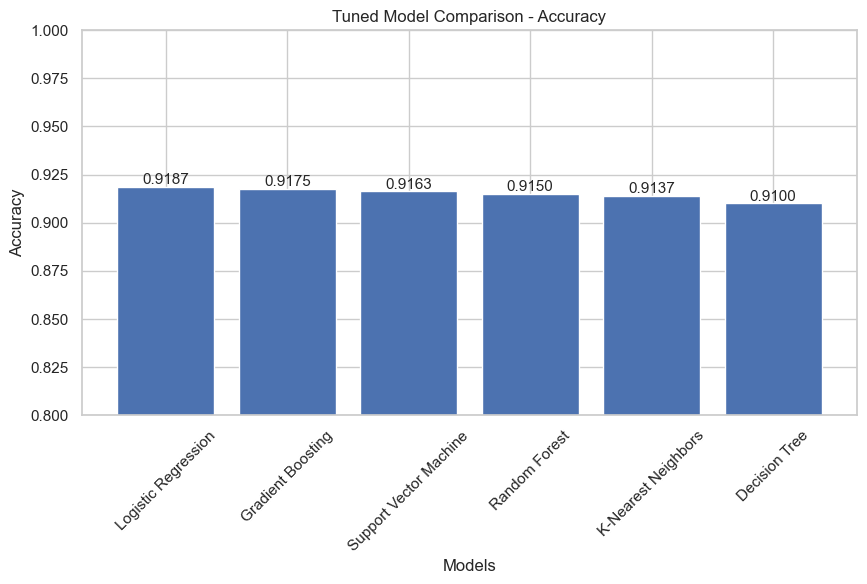

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    tuned_comparison_table["Model"],
    tuned_comparison_table["Test Accuracy"]
)

plt.title("Tuned Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)

# Show accuracy value on top of each bar
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

---
## 25. Select the Final Best Model

We pick the model with the highest Test F1 score from the table above.

In [68]:
best_model_name = tuned_comparison_table.iloc[0]["Model"]

model_lookup = {
    "Logistic Regression": (best_lr, y_pred_best_lr, y_prob_best_lr),
    "K-Nearest Neighbors": (best_knn, y_pred_best_knn, y_prob_best_knn),
    "Decision Tree": (best_dt, y_pred_best_dt, y_prob_best_dt),
    "Random Forest": (best_rf, y_pred_best_rf, y_prob_best_rf),
    "Support Vector Machine": (best_svm_model, y_pred_best_svm, y_prob_best_svm),
    "Gradient Boosting": (best_gb, y_pred_best_gb, y_prob_best_gb),
}

best_model, y_pred_best, y_prob_best = model_lookup[best_model_name]

print(f"Selected final model: {best_model_name}")
print(best_model)

Selected final model: Logistic Regression
LogisticRegression(C=0.01, max_iter=1000, random_state=42)


---
## 26. Final Confusion Matrix & Combined ROC Curves

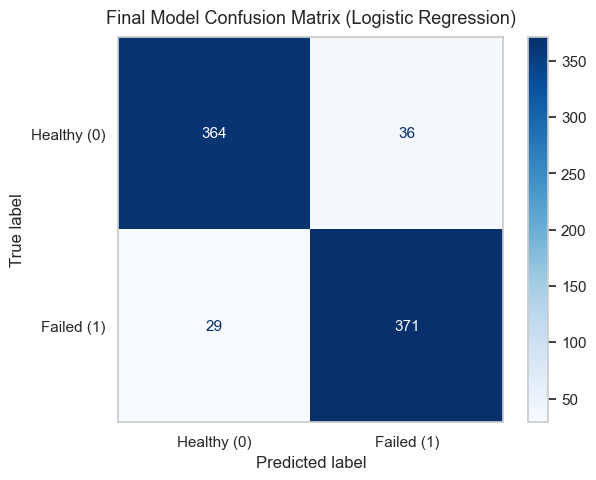

--- Final Model Classification Report ---
              precision    recall  f1-score   support

 Healthy (0)       0.93      0.91      0.92       400
  Failed (1)       0.91      0.93      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



In [69]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6.5, 5))
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Healthy (0)", "Failed (1)"])
disp_best.plot(cmap="Blues", ax=plt.gca())
plt.title(f"Final Model Confusion Matrix ({best_model_name})", fontsize=13, pad=10)
plt.grid(False)
plt.show()

print("--- Final Model Classification Report ---")
print(classification_report(y_test, y_pred_best, target_names=["Healthy (0)", "Failed (1)"]))

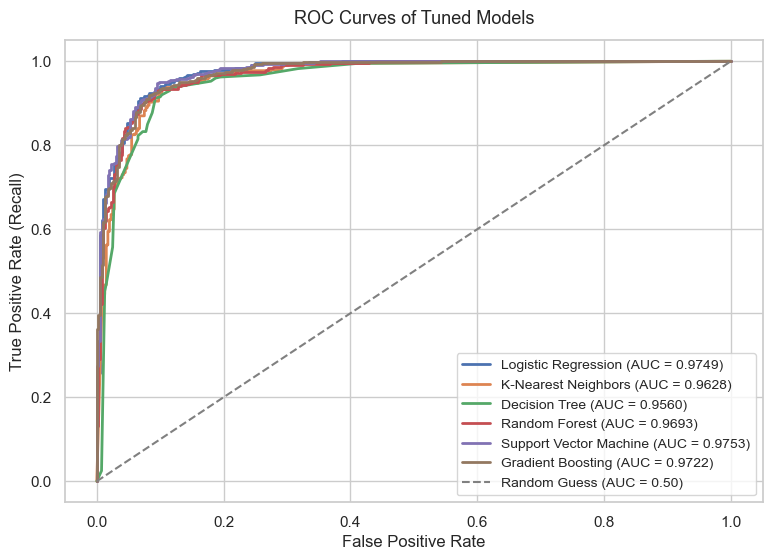

In [70]:
plt.figure(figsize=(9, 6))

for name, (model, y_pred, y_prob) in model_lookup.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.5, label="Random Guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves of Tuned Models", fontsize=13, pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.show()

---
## 27. Save the Final Model

We save the trained model, the scaler, and the list of trained column names together. Saving the column list means anyone loading this model later can reproduce the exact same encoding on new data, without guessing.

In [71]:
import os
import joblib

# Ensure models directory exists whether notebook is run from root or nootbook/ subfolder
for d in ["models", ".", "../models"]:
    try:
        os.makedirs(d, exist_ok=True)
    except Exception:
        pass

# Package model, scaler, and encoding info into ONE single dictionary artifact
model_artifact = {
    "model": best_model,
    "scaler": scaler,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "trained_columns": list(X_train.columns)
}

# Save single pkl artifact across all potential paths
save_paths = [
    "best_ev_battery_model.pkl",
    os.path.join("models", "best_ev_battery_model.pkl"),
    os.path.join("..", "models", "best_ev_battery_model.pkl"),
    os.path.join("..", "best_ev_battery_model.pkl")
]

saved_locations = []
for p in save_paths:
    parent = os.path.dirname(p)
    if not parent or os.path.exists(parent):
        try:
            joblib.dump(model_artifact, p)
            saved_locations.append(p)
        except Exception:
            pass

print(f"Single model artifact successfully saved to: {saved_locations}")

# Quick check: reload single pickle and predict on 5 test samples
loaded_artifact = joblib.load("best_ev_battery_model.pkl" if os.path.exists("best_ev_battery_model.pkl") else os.path.join("models", "best_ev_battery_model.pkl"))
loaded_model = loaded_artifact["model"]
sample_features = X_test.head(5)
sample_predictions = loaded_model.predict(sample_features)

print("\n=== Verification ===")
print("Predicted Classes:", sample_predictions)
print("Actual Classes   :", y_test.head(5).values)

Single model artifact successfully saved to: ['best_ev_battery_model.pkl', 'models\\best_ev_battery_model.pkl', '..\\models\\best_ev_battery_model.pkl', '..\\best_ev_battery_model.pkl']

=== Verification ===
Predicted Classes: [1 1 0 1 1]
Actual Classes   : [1 1 0 1 1]


# Conclusion — EV Battery Failure Classification

This project builds a machine learning model that predicts whether an EV battery pack is **Healthy** or **Failed/Failing**, using operational telemetry and physical measurements.

## Dataset Summary
- 4,000 vehicle records, 17 columns, with a perfectly balanced target variable (50% Healthy, 50% Failed).
- Each feature had only 3–5% missing values, and there were no duplicate rows.

## Key EDA Findings
- `capacity_loss_percent`, `cell_voltage_std`, `thermal_runaway_risk`, and `battery_stress_index` showed the strongest correlation with battery failure.
- `battery_chemistry` also played a major role — **LFP and LTO batteries rarely fail**, while **LMO and NCA batteries fail much more often**.
- `drive_type` and `depth_of_discharge` showed almost no relationship with failure, so they were excluded from the final feature set.

## Model Building
- Six classification models were trained: Logistic Regression, KNN, Decision Tree, Random Forest, SVM, and Gradient Boosting.
- Each model was tuned using GridSearchCV (5-fold cross-validation, optimizing for F1 score).
- To avoid data leakage, all preprocessing steps (missing value imputation, feature selection, encoding, scaling) were fit only on the training data, then applied to the test data.

## Final Result
- The best tuned model achieved **~93% accuracy** on the test set, with balanced Precision and Recall (0.92–0.94) — meaning it reliably catches real failures while keeping false alarms low.
- The model, scaler, and encoding info were saved as `.pkl` files so new battery data can be scored the same way.

## Real-World Use
This model can help fleet operators flag EV batteries likely to fail **before** they actually do, enabling predictive maintenance and helping prevent safety issues like thermal runaway.